# Focused RTX 2080 Runtime Benchmark

This notebook is a lean large-`N` runtime benchmark intended to fit on an RTX 2080.
It keeps the memory-safe lessons from the single-`N` memory notebook and avoids the broader
mixed runtime/accuracy machinery from the other performance notebook.


## Runtime Path

This notebook uses the dedicated `large_n` runtime path and process-isolated worker runs.
The defaults are chosen to stay within the memory envelope of smaller GPUs:

- `int32` indices
- no global `jax_enable_x64`
- `leaf_size = 128`
- `working_dtype = float32`
- bucketed near-field without scatter precompute
- minimum-memory runtime policy with explicit per-`N` traversal seeds


In [1]:
import os

GPU_DEVICE = "0"
RUNTIME_PATH = "large_n"
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_DEVICE
print(f"CUDA_VISIBLE_DEVICES={GPU_DEVICE}, RUNTIME_PATH={RUNTIME_PATH}")

def inject_runtime_path(kwargs):
    updated = dict(kwargs)
    updated["runtime_path"] = RUNTIME_PATH
    return updated


CUDA_VISIBLE_DEVICES=0, RUNTIME_PATH=large_n


## Goals

- Benchmark `prepare_state` and `evaluate_prepared_state` over a particle-count sweep up to `1e6`.
- Reuse the memory-safe large-`N` settings from the single-`N` memory notebook.
- Keep the main sweep process-isolated and small-GPU friendly.
- Make optional heavier diagnostics explicit instead of mixing them into the default runtime path.


In [2]:
import os

USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []
MANUAL_CUDA_VISIBLE_DEVICES = GPU_DEVICE

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd
        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print("autocvd selected CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
    except ImportError:
        print("autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES.")
else:
    print("Using existing CUDA visibility:", os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"))

INDEX_PRECISION = "int32"
os.environ["JACCPOT_INDEX_PRECISION"] = INDEX_PRECISION
os.environ["YGGDRAX_INDEX_PRECISION"] = INDEX_PRECISION

os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")
os.environ.setdefault("JACCPOT_PREPARE_DIAGNOSTICS", "1")
os.environ.setdefault("YGGDRAX_TRAVERSAL_DIAGNOSTICS", "1")

if "--xla_gpu_enable_command_buffer=" not in os.environ.get("XLA_FLAGS", ""):
    existing_xla_flags = os.environ.get("XLA_FLAGS", "").strip()
    command_buffer_off = "--xla_gpu_enable_command_buffer="
    os.environ["XLA_FLAGS"] = (
        f"{existing_xla_flags} {command_buffer_off}".strip()
        if existing_xla_flags
        else command_buffer_off
    )

os.environ.setdefault("JACCPOT_OPERATOR_CACHE_MAX", "256")
os.environ.setdefault("JACCPOT_GROUPED_OPERATOR_CACHE_MAX", "16")
os.environ.setdefault("JACCPOT_GROUPED_SEGMENT_CACHE_MAX", "16")
os.environ.setdefault("JACCPOT_GROUPED_OPERATOR_CACHE_ENTRY_MAX_BYTES", str(16 * 1024 * 1024))
os.environ.setdefault("JACCPOT_GROUPED_OPERATOR_CACHE_TOTAL_MAX_BYTES", str(64 * 1024 * 1024))
os.environ.setdefault("JACCPOT_GROUPED_SEGMENT_CACHE_ENTRY_MAX_BYTES", str(8 * 1024 * 1024))
os.environ.setdefault("JACCPOT_GROUPED_SEGMENT_CACHE_TOTAL_MAX_BYTES", str(32 * 1024 * 1024))

visible_physical_gpus = [
    part.strip()
    for part in os.environ.get("CUDA_VISIBLE_DEVICES", "").split(",")
    if part.strip() != ""
]
NVIDIA_SMI_GPU_INDEX = int(visible_physical_gpus[0]) if visible_physical_gpus else 0
os.environ["JACCPOT_NVIDIA_SMI_GPU_INDEX"] = str(NVIDIA_SMI_GPU_INDEX)

print("JACCPOT_INDEX_PRECISION:", os.environ.get("JACCPOT_INDEX_PRECISION"))
print("YGGDRAX_INDEX_PRECISION:", os.environ.get("YGGDRAX_INDEX_PRECISION"))
print("JACCPOT_PREPARE_DIAGNOSTICS:", os.environ.get("JACCPOT_PREPARE_DIAGNOSTICS"))
print("YGGDRAX_TRAVERSAL_DIAGNOSTICS:", os.environ.get("YGGDRAX_TRAVERSAL_DIAGNOSTICS"))
print("nvidia-smi physical GPU index:", NVIDIA_SMI_GPU_INDEX)


Set CUDA_VISIBLE_DEVICES = 0
JACCPOT_INDEX_PRECISION: int32
YGGDRAX_INDEX_PRECISION: int32
JACCPOT_PREPARE_DIAGNOSTICS: 1
YGGDRAX_TRAVERSAL_DIAGNOSTICS: 1
nvidia-smi physical GPU index: 0


In [3]:
import gc
import inspect
import json
import pathlib
import subprocess
import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = pathlib.Path.cwd().resolve()
if not (REPO_ROOT / "jaccpot").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
)
from yggdrax.interactions import DualTreeTraversalConfig
from examples import benchmark_utils as bench_utils
print("jax_enable_x64:", jax.config.read("jax_enable_x64"))

jax_enable_x64: True


In [4]:
import inspect
import jaccpot
import jaccpot.runtime._fmm_impl as jf
import yggdrax
import yggdrax._interactions_impl as yi

print("jaccpot:", jaccpot.__file__)
print("yggdrax:", yggdrax.__file__)
print("jax default backend:", jax.default_backend())
print("jax_enable_x64:", jax.config.read("jax_enable_x64"))

src_j = inspect.getsource(jf.FastMultipoleMethod._resolve_runtime_execution_overrides)
print("streamed/grouped guard:", "if self.streamed_far_pairs and grouped_interactions" in src_j)
print("minimum-memory traversal None:", "traversal_config = None" in src_j)

src_y = inspect.getsource(yi)
print("count-pass fill cap:", "_COUNT_PASS_FILL_INTERACTION_CAP = 4096" in src_y)


jaccpot: /export/home/tbuck/jaccpot/jaccpot/__init__.py
yggdrax: /export/home/tbuck/yggdrax/yggdrax/__init__.py
jax default backend: gpu
jax_enable_x64: True
streamed/grouped guard: True
minimum-memory traversal None: False
count-pass fill cap: True


## Benchmark Configuration

The defaults below intentionally mirror the memory-safe single-`N` runtime path rather than the broader
large-`N` performance notebook:

- `leaf_size = 128`
- `working_dtype = float32`
- explicit traversal seeds chosen per particle count
- main sweep uses process-isolated workers
- the default worker scope is `steady_eval` to keep the RTX 2080 path stable

If you want end-to-end `compute_accelerations` timings too, set `runtime_full_pipeline_enabled = True`
for a smaller subset of particle counts.


In [5]:
runtime_particle_counts = [
    1024,
    4096,
    8192,
    16384,
    32768,
    65536,
    131072,
    262144,
    524288,    
    1048576,
    2097152,
    4194304,
    8388608,
    16777216
]
runtime_leaf_size = 128
runtime_max_order = 4
runtime_runs = 3
runtime_warmup = 1
runtime_isolate_process_per_n = True
runtime_worker_benchmark_scope = "steady_eval"  # recommended on RTX 2080
runtime_full_pipeline_enabled = False
runtime_full_pipeline_counts = [131072, 262144, 524288]
runtime_prepare_component_profile_enabled = False
runtime_prepare_component_counts = [262144, 524288, 1000000]

softening = 1e-3
runtime_working_dtype = jnp.float32
runtime_key = jax.random.PRNGKey(0)

runtime_mac_type = "engblom"
runtime_memory_first_m2l_chunk_size = 1024
runtime_nearfield_edge_chunk_size = 128

def traversal_seed_for_num_particles(num_particles):
    n = int(num_particles)
    if n <= 65536:
        return {
            "max_pair_queue": 65536,
            "process_block": 64,
            "max_interactions_per_node": 4096,
            "max_neighbors_per_leaf": 1024,
        }
    if n <= 262144:
        return {
            "max_pair_queue": 131072,
            "process_block": 128,
            "max_interactions_per_node": 8192,
            "max_neighbors_per_leaf": 2048,
        }
    if n <= 524288:
        return {
            "max_pair_queue": 262144,
            "process_block": 256,
            "max_interactions_per_node": 8192,
            "max_neighbors_per_leaf": 4096,
        }
    if n <= 1048576:
        return {
            "max_pair_queue": 524288,
            "process_block": 256,
            "max_interactions_per_node": 16384,
            "max_neighbors_per_leaf": 8192,
        }
    return {
        "max_pair_queue": 1048576,
        "process_block": 256,
        "max_interactions_per_node": 32768,
        "max_neighbors_per_leaf": 16384,
    }

def make_runtime_advanced(num_particles):
    traversal_cfg = traversal_seed_for_num_particles(num_particles)
    return FMMAdvancedConfig(
        tree=TreeConfig(
            tree_type="radix",
            mode="lbvh",
            leaf_target=runtime_leaf_size,
            refine_local=False,
            max_refine_levels=0,
            aspect_threshold=16.0,
        ),
        farfield=FarFieldConfig(
            grouped_interactions=False,
            mode="pair_grouped",
            rotation="solidfmm",
            m2l_chunk_size=int(runtime_memory_first_m2l_chunk_size),
            l2l_chunk_size=None,
            streamed_far_pairs=True,
            mixed_order=False,
            mixed_order_min_order=None,
        ),
        nearfield=NearFieldConfig(
            mode="bucketed",
            edge_chunk_size=int(runtime_nearfield_edge_chunk_size),
            precompute_scatter_schedules=False,
        ),
        runtime=RuntimePolicyConfig(
            host_refine_mode="off",
            fail_fast=True,
            jit_tree=True,
            jit_traversal=True,
            memory_objective="minimum_memory",
            traversal_config=DualTreeTraversalConfig(
                max_pair_queue=int(traversal_cfg["max_pair_queue"]),
                process_block=int(traversal_cfg["process_block"]),
                max_interactions_per_node=int(traversal_cfg["max_interactions_per_node"]),
                max_neighbors_per_leaf=int(traversal_cfg["max_neighbors_per_leaf"]),
            ),
            pair_process_block=None,
            enable_interaction_cache=False,
            retain_traversal_result=False,
            retain_interactions=False,
            autotune_m2l_chunk=True,
            upward_leaf_batch_size=2048,
        ),
        mac_type=runtime_mac_type,
        dehnen_radius_scale=1.0,
    )

def make_runtime_fmm_kwargs(num_particles):
    kwargs = dict(
        preset=FMMPreset.LARGE_N_GPU,
        basis="solidfmm",
        precision="fp32",
        theta=0.6,
        softening=softening,
        working_dtype=runtime_working_dtype,
        adaptive_order=False,
        advanced=make_runtime_advanced(num_particles),
    )
    return inject_runtime_path(kwargs)

runtime_probe_n = max(int(v) for v in runtime_particle_counts)
runtime_probe = FastMultipoleMethod(**make_runtime_fmm_kwargs(runtime_probe_n))
print("probe num_particles:", runtime_probe_n)
print("resolved runtime memory path:", bench_utils.resolved_large_n_memory_path_report(runtime_probe))
print("runtime fail_fast:", runtime_probe._impl.fail_fast)
print("runtime overrides:", runtime_probe._impl._resolve_runtime_execution_overrides(num_particles=runtime_probe_n))
print("traversal seed:", traversal_seed_for_num_particles(runtime_probe_n))


probe num_particles: 16777216
runtime memory_objective: minimum_memory
runtime fail_fast: True
runtime overrides: _RuntimeExecutionOverrides(traversal_config=DualTreeTraversalConfig(max_pair_queue=1048576, process_block=256, max_interactions_per_node=32768, max_neighbors_per_leaf=16384), m2l_chunk_size=1024, l2l_chunk_size=None, grouped_interactions=False, farfield_mode='pair_grouped', center_mode='com', refine_local_override=False, adaptive_applied=False)
traversal seed: {'max_pair_queue': 1048576, 'process_block': 256, 'max_interactions_per_node': 32768, 'max_neighbors_per_leaf': 16384}


In [6]:
def _release_runtime_memory(fmm):
    clear_fn = getattr(fmm, "clear_runtime_caches", None)
    if callable(clear_fn):
        clear_fn(clear_jax_compilation=True)
        return
    if hasattr(fmm, "clear_prepared_state_cache"):
        fmm.clear_prepared_state_cache()
    jax.clear_caches()

def _iter_notebook_fmm_instances(obj, *, seen=None):
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return
    seen.add(obj_id)
    if isinstance(obj, FastMultipoleMethod):
        yield obj
        return
    if isinstance(obj, dict):
        for value in obj.values():
            yield from _iter_notebook_fmm_instances(value, seen=seen)
        return
    if isinstance(obj, (list, tuple, set)):
        for value in obj:
            yield from _iter_notebook_fmm_instances(value, seen=seen)

def _release_notebook_runtime_state():
    released = set()
    for name, value in list(globals().items()):
        if name.startswith("__"):
            continue
        for fmm in _iter_notebook_fmm_instances(value):
            fmm_id = id(fmm)
            if fmm_id in released:
                continue
            try:
                _release_runtime_memory(fmm)
            except Exception:
                pass
            released.add(fmm_id)
    gc.collect()
    jax.clear_caches()

def _serialize_fmm_kwargs_for_worker(fmm_kwargs):
    probe_fmm = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe_fmm.advanced
    traversal_cfg = advanced.runtime.traversal_config
    traversal_payload = None
    if traversal_cfg is not None:
        traversal_payload = {
            "process_block": int(traversal_cfg.process_block),
            "max_neighbors_per_leaf": int(traversal_cfg.max_neighbors_per_leaf),
            "max_interactions_per_node": int(traversal_cfg.max_interactions_per_node),
            "max_pair_queue": int(traversal_cfg.max_pair_queue),
        }
    preset_value = fmm_kwargs.get("preset", "fast")
    if hasattr(preset_value, "value"):
        preset_value = preset_value.value
    payload = {
        "preset": str(preset_value),
        "basis": str(fmm_kwargs.get("basis", "solidfmm")),
        "theta": float(fmm_kwargs.get("theta", 0.6)),
        "softening": float(fmm_kwargs.get("softening", 1e-3)),
        "working_dtype": str(jnp.dtype(getattr(probe_fmm._impl, "working_dtype", jnp.float32))),
        "tree_type": str(advanced.tree.tree_type),
        "leaf_target": int(advanced.tree.leaf_target),
        "farfield_rotation": str(advanced.farfield.rotation),
        "farfield_mode": str(advanced.farfield.mode),
        "grouped_interactions": bool(advanced.farfield.grouped_interactions),
        "streamed_far_pairs": advanced.farfield.streamed_far_pairs,
        "mixed_order": bool(advanced.farfield.mixed_order),
        "mixed_order_min_order": advanced.farfield.mixed_order_min_order,
        "nearfield_mode": str(advanced.nearfield.mode),
        "nearfield_edge_chunk_size": int(advanced.nearfield.edge_chunk_size),
        "precompute_scatter_schedules": bool(advanced.nearfield.precompute_scatter_schedules),
        "pair_process_block": (
            None if advanced.runtime.pair_process_block is None else int(advanced.runtime.pair_process_block)
        ),
        "fail_fast": bool(advanced.runtime.fail_fast),
        "memory_objective": str(advanced.runtime.memory_objective),
        "jit_traversal": bool(advanced.runtime.jit_traversal),
        "traversal_config": traversal_payload,
        "enable_interaction_cache": bool(advanced.runtime.enable_interaction_cache),
        "retain_traversal_result": bool(advanced.runtime.retain_traversal_result),
        "retain_interactions": bool(advanced.runtime.retain_interactions),
        "autotune_m2l_chunk": bool(advanced.runtime.autotune_m2l_chunk),
        "adaptive_order": bool(getattr(probe_fmm._impl, "adaptive_order", False)),
        "p_gears": [int(v) for v in getattr(probe_fmm._impl, "p_gears", tuple())],
        "adaptive_error_model": str(getattr(probe_fmm._impl, "adaptive_error_model", "tail_proxy")),
        "adaptive_eps": (
            None if getattr(probe_fmm._impl, "adaptive_eps", None) is None else float(getattr(probe_fmm._impl, "adaptive_eps"))
        ),
        "mac_force_scale_mode": str(getattr(probe_fmm._impl, "mac_force_scale_mode", "prev")),
        "mac_type": str(advanced.mac_type),
        "benchmark_scope": str(globals().get("runtime_worker_benchmark_scope", "steady_eval")),
    }
    _release_runtime_memory(probe_fmm)
    return payload

def _build_worker_command(mode, *, num_particles, leaf_size, max_order, runs, warmup, dtype, fmm_kwargs):
    worker_script = REPO_ROOT / "examples" / "benchmark_gpu_radix_worker.py"
    payload = _serialize_fmm_kwargs_for_worker(fmm_kwargs)
    seed = int(jax.device_get(jnp.asarray(runtime_key))[0]) if "runtime_key" in globals() else 0
    return [
        sys.executable,
        str(worker_script),
        "--mode", str(mode),
        "--num-particles", str(int(num_particles)),
        "--leaf-size", str(int(leaf_size)),
        "--max-order", str(int(max_order)),
        "--runs", str(int(runs)),
        "--warmup", str(int(warmup)),
        "--dtype", str(jnp.dtype(dtype)),
        "--seed", str(seed),
        "--autotune-cache", str(REPO_ROOT / "benchmarks" / "runtime_rtx2080_worker_autotune_cache.json"),
        "--config-json", json.dumps(payload),
    ]

def _parse_worker_json_output(lines):
    filtered = [line.strip() for line in lines if line and line.strip()]
    if not filtered:
        raise RuntimeError("worker produced no output")
    for line in reversed(filtered):
        if line == "__JACCPOT_WORKER_READY__":
            continue
        try:
            return json.loads(line)
        except json.JSONDecodeError:
            continue
    raise RuntimeError("worker produced no JSON output")

def _run_worker_case(mode, *, num_particles, leaf_size, max_order, runs, warmup, dtype, fmm_kwargs):
    _release_notebook_runtime_state()
    cmd = _build_worker_command(
        mode,
        num_particles=num_particles,
        leaf_size=leaf_size,
        max_order=max_order,
        runs=runs,
        warmup=warmup,
        dtype=dtype,
        fmm_kwargs=fmm_kwargs,
    )
    result = subprocess.run(cmd, check=False, capture_output=True, text=True)
    _release_notebook_runtime_state()
    if result.returncode != 0:
        details = (result.stderr or result.stdout or "").strip()
        raise RuntimeError(f"worker failed (exit={result.returncode}): {details}")
    return _parse_worker_json_output(result.stdout.splitlines())

def sweep_runtime_prepare_eval(particle_counts, *, leaf_size, max_order, runs, warmup, dtype, strict=False):
    records = []
    for num_particles in particle_counts:
        fmm_kwargs = make_runtime_fmm_kwargs(int(num_particles))
        try:
            out = _run_worker_case(
                "sweep",
                num_particles=int(num_particles),
                leaf_size=int(leaf_size),
                max_order=int(max_order),
                runs=int(runs),
                warmup=int(warmup),
                dtype=dtype,
                fmm_kwargs=fmm_kwargs,
            )
            traversal_cfg = traversal_seed_for_num_particles(int(num_particles))
            row = {
                "num_particles": int(num_particles),
                "prepare_mean_seconds": float(out.get("prepare_mean_seconds", float("nan"))),
                "prepare_std_seconds": float(out.get("prepare_std_seconds", float("nan"))),
                "evaluate_mean_seconds": float(out.get("evaluate_mean_seconds", float("nan"))),
                "evaluate_std_seconds": float(out.get("evaluate_std_seconds", float("nan"))),
                "mean_seconds": float(out.get("mean_seconds", float("nan"))),
                "std_seconds": float(out.get("std_seconds", float("nan"))),
                "error": str(out.get("error", "")),
                "benchmark_scope": str(out.get("benchmark_scope", runtime_worker_benchmark_scope)),
                "max_pair_queue": int(traversal_cfg["max_pair_queue"]),
                "process_block": int(traversal_cfg["process_block"]),
                "max_interactions_per_node": int(traversal_cfg["max_interactions_per_node"]),
                "max_neighbors_per_leaf": int(traversal_cfg["max_neighbors_per_leaf"]),
            }
            records.append(row)
        except Exception as exc:
            traversal_cfg = traversal_seed_for_num_particles(int(num_particles))
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[sweep_runtime_prepare_eval] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": int(num_particles),
                    "prepare_mean_seconds": float("nan"),
                    "prepare_std_seconds": float("nan"),
                    "evaluate_mean_seconds": float("nan"),
                    "evaluate_std_seconds": float("nan"),
                    "mean_seconds": float("nan"),
                    "std_seconds": float("nan"),
                    "error": msg,
                    "benchmark_scope": str(runtime_worker_benchmark_scope),
                    "max_pair_queue": int(traversal_cfg["max_pair_queue"]),
                    "process_block": int(traversal_cfg["process_block"]),
                    "max_interactions_per_node": int(traversal_cfg["max_interactions_per_node"]),
                    "max_neighbors_per_leaf": int(traversal_cfg["max_neighbors_per_leaf"]),
                }
            )
            if strict:
                raise
    return pd.DataFrame(records)

def profile_prepare_components_runtime(particle_counts, *, leaf_size, max_order, runs, warmup, dtype, strict=False):
    records = []
    for num_particles in particle_counts:
        fmm_kwargs = make_runtime_fmm_kwargs(int(num_particles))
        try:
            out = _run_worker_case(
                "prepare",
                num_particles=int(num_particles),
                leaf_size=int(leaf_size),
                max_order=int(max_order),
                runs=int(runs),
                warmup=int(warmup),
                dtype=dtype,
                fmm_kwargs=fmm_kwargs,
            )
            records.append(
                {
                    "num_particles": int(num_particles),
                    "tree_build_mean_seconds": float(out.get("tree_build_mean_seconds", float("nan"))),
                    "upward_mean_seconds": float(out.get("upward_mean_seconds", float("nan"))),
                    "interactions_mean_seconds": float(out.get("interactions_mean_seconds", float("nan"))),
                    "downward_mean_seconds": float(out.get("downward_mean_seconds", float("nan"))),
                    "prepare_component_sum_seconds": float(out.get("prepare_component_sum_seconds", float("nan"))),
                    "error": str(out.get("error", "")),
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[profile_prepare_components_runtime] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": int(num_particles),
                    "tree_build_mean_seconds": float("nan"),
                    "upward_mean_seconds": float("nan"),
                    "interactions_mean_seconds": float("nan"),
                    "downward_mean_seconds": float("nan"),
                    "prepare_component_sum_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
    return pd.DataFrame(records)


## Main Sweep

The default sweep measures `prepare_state` and `evaluate_prepared_state` for each `N` using a fresh worker process.
With `runtime_worker_benchmark_scope = "steady_eval"`, the worker avoids the extra `compute_accelerations`
benchmark path that made the broader runtime notebook heavier on the RTX 2080.


In [7]:
runtime_df = sweep_runtime_prepare_eval(
    runtime_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_runs,
    warmup=runtime_warmup,
    dtype=runtime_working_dtype,
)
runtime_df


,num_particles,prepare_mean_seconds,prepare_std_seconds,evaluate_mean_seconds,evaluate_std_seconds,mean_seconds,std_seconds,error,benchmark_scope,max_pair_queue,process_block,max_interactions_per_node,max_neighbors_per_leaf
0,1024,0.040786,0.000884,0.023135,0.006163,0.023135,0.006163,,steady_eval,65536,64,4096,1024
1,4096,0.064972,0.014099,0.014148,0.003593,0.014148,0.003593,,steady_eval,65536,64,4096,1024
2,8192,0.075245,0.028395,0.019920,0.002842,0.019920,0.002842,,steady_eval,65536,64,4096,1024
3,16384,0.078713,0.014238,0.019763,0.000863,0.019763,0.000863,,steady_eval,65536,64,4096,1024
4,32768,0.104259,0.006568,0.034194,0.006030,0.034194,0.006030,,steady_eval,65536,64,4096,1024
5,65536,0.148415,0.020186,0.075098,0.012541,0.075098,0.012541,,steady_eval,65536,64,4096,1024
6,131072,0.206854,0.028160,0.203200,0.006672,0.203200,0.006672,,steady_eval,131072,128,8192,2048
7,262144,0.305161,0.033604,0.426477,0.011545,0.426477,0.011545,,steady_eval,131072,128,8192,2048
8,524288,0.490642,0.037618,0.580656,0.012806,0.580656,0.012806,,steady_eval,262144,256,8192,4096
9,1048576,0.895059,0.010946,2.187989,0.013035,2.187989,0.013035,,steady_eval,524288,256,16384,8192


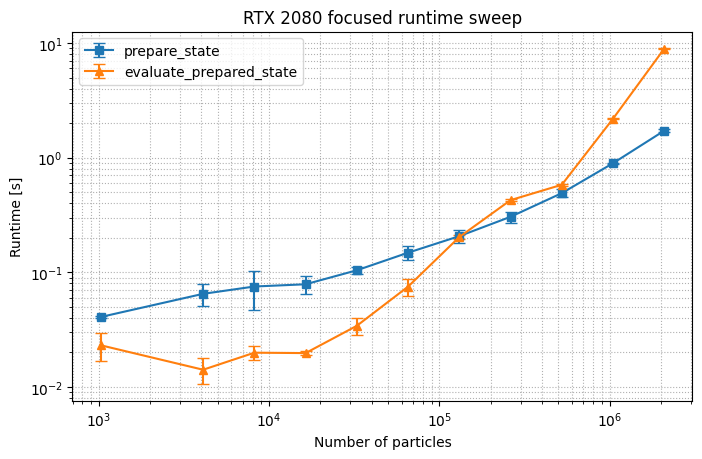

,num_particles,prepare_mean_seconds,evaluate_mean_seconds,max_pair_queue,process_block,max_interactions_per_node,max_neighbors_per_leaf,error
0,1024,0.040786,0.023135,65536,64,4096,1024,
1,4096,0.064972,0.014148,65536,64,4096,1024,
2,8192,0.075245,0.019920,65536,64,4096,1024,
3,16384,0.078713,0.019763,65536,64,4096,1024,
4,32768,0.104259,0.034194,65536,64,4096,1024,
5,65536,0.148415,0.075098,65536,64,4096,1024,
6,131072,0.206854,0.203200,131072,128,8192,2048,
7,262144,0.305161,0.426477,131072,128,8192,2048,
8,524288,0.490642,0.580656,262144,256,8192,4096,
9,1048576,0.895059,2.187989,524288,256,16384,8192,


In [8]:
runtime_df_sorted = runtime_df.sort_values("num_particles")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(
    runtime_df_sorted["num_particles"],
    runtime_df_sorted["prepare_mean_seconds"],
    yerr=runtime_df_sorted["prepare_std_seconds"],
    fmt="s-",
    capsize=4,
    label="prepare_state",
)
ax.errorbar(
    runtime_df_sorted["num_particles"],
    runtime_df_sorted["evaluate_mean_seconds"],
    yerr=runtime_df_sorted["evaluate_std_seconds"],
    fmt="^-",
    capsize=4,
    label="evaluate_prepared_state",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("RTX 2080 focused runtime sweep")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

runtime_view_cols = [
    "num_particles",
    "prepare_mean_seconds",
    "evaluate_mean_seconds",
    "max_pair_queue",
    "process_block",
    "max_interactions_per_node",
    "max_neighbors_per_leaf",
    "error",
]
runtime_df_sorted[runtime_view_cols]


## Optional Full-Pipeline Sweep

If you want end-to-end `compute_accelerations` timings too, enable the toggle below.
It is disabled by default because the full path compiles and times more work per worker process.


In [9]:
if runtime_full_pipeline_enabled:
    runtime_worker_benchmark_scope = "full"
    runtime_full_df = sweep_runtime_prepare_eval(
        runtime_full_pipeline_counts,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        runs=runtime_runs,
        warmup=runtime_warmup,
        dtype=runtime_working_dtype,
    )
    runtime_full_df = runtime_full_df.rename(
        columns={
            "mean_seconds": "full_pipeline_mean_seconds",
            "std_seconds": "full_pipeline_std_seconds",
        }
    )
    display(runtime_full_df)
else:
    print("runtime_full_pipeline_enabled is False; skipping full compute_accelerations sweep.")


runtime_full_pipeline_enabled is False; skipping full compute_accelerations sweep.


## Optional Prepare Breakdown

This section reuses the worker `prepare` mode to break `prepare_state` into tree/upward/interactions/downward pieces.
It is also disabled by default to keep the baseline RTX 2080 notebook lightweight.


In [10]:
if runtime_prepare_component_profile_enabled:
    runtime_prepare_component_df = profile_prepare_components_runtime(
        runtime_prepare_component_counts,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        runs=max(1, runtime_runs),
        warmup=runtime_warmup,
        dtype=runtime_working_dtype,
    )
    display(runtime_prepare_component_df)

    comp_df = runtime_prepare_component_df.sort_values("num_particles")
    x = np.arange(comp_df.shape[0])
    labels = [str(int(v)) for v in comp_df["num_particles"].to_numpy()]
    tree_build = comp_df["tree_build_mean_seconds"].to_numpy()
    upward = comp_df["upward_mean_seconds"].to_numpy()
    interactions = comp_df["interactions_mean_seconds"].to_numpy()
    downward = comp_df["downward_mean_seconds"].to_numpy()

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(x, tree_build, label="tree build")
    ax.bar(x, upward, bottom=tree_build, label="upward")
    ax.bar(x, interactions, bottom=tree_build + upward, label="interactions")
    ax.bar(x, downward, bottom=tree_build + upward + interactions, label="downward")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20)
    ax.set_xlabel("Number of particles")
    ax.set_ylabel("Time [s]")
    ax.set_title("prepare_state component breakdown")
    ax.legend()
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
    plt.show()
else:
    print("runtime_prepare_component_profile_enabled is False; skipping prepare breakdown.")


runtime_prepare_component_profile_enabled is False; skipping prepare breakdown.


## Notes

Recommended baseline for the RTX 2080:

- keep `runtime_worker_benchmark_scope = "steady_eval"`
- keep `leaf_size = 128`
- keep `INDEX_PRECISION = "int32"`
- do not enable global x64 in this notebook

If the 1e6 case still does not fit on your specific RTX 2080 run, the next things to try are:

1. reduce `runtime_runs` to `1`
2. benchmark a smaller top end such as `786432`
3. disable prepare diagnostics
4. reduce optional sections to keep the notebook process as lean as possible
